In [1]:
import os
from collections import defaultdict
from itertools import chain

import polars as pl

from social_groups.analysis.polars_transformations import make_group_constellation
from social_groups.reporting.analysis_columns import AnalysisColumn
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
    SingularityVote,
)
from social_groups.reporting.parsing import (
    AnswerOptions,
    AnswerParser,
    AnswerComparer,
)
from social_groups.directories import REPORTING_DIR
from social_groups.polars_values import MODEL_NAME_TO_LETTER_MAPPING
from social_groups.reporting.group_decision_scheme import calculate_decision_scheme

from social_groups.analysis.polars_transformations.apply_parsing_and_group_decision import (
    apply_parsing_and_group_decision,
)
import social_groups.polars_values as plv
import social_groups.polars_columns as plc

%load_ext autoreload
%autoreload 2

In [2]:
triple_underscore_handling = "wrong"

parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling=triple_underscore_handling
)

In [3]:
from social_groups.analysis.definitions import defs

thinking_frame: pl.DataFrame = defs.load_fn().load_asset_value("thinking_mad")

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:111: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-02-21 19:36:50 +0800 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/thinking_mad.parquet using PolarsParquetIOManager...


In [4]:
thinking_frame

shape: (6_400, 18)
┌───────┬────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ id    ┆ run_id ┆ question_i ┆ phoenix_sp ┆ … ┆ question   ┆ answer_str ┆ thinking_m ┆ group_cons │
│ ---   ┆ ---    ┆ d          ┆ an_id      ┆   ┆ ---        ┆ ing        ┆ odels      ┆ tellation  │
│ i64   ┆ i64    ┆ ---        ┆ ---        ┆   ┆ str        ┆ ---        ┆ ---        ┆ ---        │
│       ┆        ┆ i64        ┆ str        ┆   ┆            ┆ str        ┆ str        ┆ str        │
╞═══════╪════════╪════════════╪════════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 4020  ┆ 57     ┆ 0          ┆ 45942f7c45 ┆ … ┆ Q: What    ┆ J          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 3b81f3     ┆   ┆ stable     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ isotope is ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ comm…      ┆            ┆            ┆            │
│ 4021  ┆ 57     ┆ 12         ┆ 52ca872339 ┆ … ┆ Q: What    ┆ B          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ e4b0d9     ┆   ┆ will       ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ happen to  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ the equ…   ┆            ┆            ┆            │
│ 4022  ┆ 57     ┆ 11         ┆ 8a1a264ccf ┆ … ┆ Q: In      ┆ C          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 2cda6c     ┆   ┆ building a ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ linear     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ regres…    ┆            ┆            ┆            │
│ 4023  ┆ 57     ┆ 17         ┆ c2d224ef0a ┆ … ┆ Q: An      ┆ I          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 3056ff     ┆   ┆ electric   ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ dipole     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ consisti…  ┆            ┆            ┆            │
│ 4024  ┆ 57     ┆ 5          ┆ 57a4af65ef ┆ … ┆ Q:  When   ┆ A          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 83e8f7     ┆   ┆ was the    ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ major      ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ shift b…   ┆            ┆            ┆            │
│ …     ┆ …      ┆ …          ┆ …          ┆ … ┆ …          ┆ …          ┆ …          ┆ …          │
│ 10975 ┆ 141    ┆ 67         ┆ 5d467246c0 ┆ … ┆ Q: What is ┆ F          ┆ everyone   ┆ LMM        │
│       ┆        ┆            ┆ bfef16     ┆   ┆ the        ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ elasticity ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ of d…      ┆            ┆            ┆            │
│ 10976 ┆ 141    ┆ 96         ┆ 392806cc02 ┆ … ┆ Q: This    ┆ H          ┆ everyone   ┆ LMM        │
│       ┆        ┆            ┆ fc6296     ┆   ┆ question   ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ refers to  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ the…       ┆            ┆            ┆            │
│ 10977 ┆ 141    ┆ 77         ┆ 66dd2435a4 ┆ … ┆ Q: Adams   ┆ D          ┆ everyone   ┆ LMM        │
│       ┆        ┆            ┆ 88da31     ┆   ┆ Manufactur ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ ing        ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ Company…   ┆            ┆            ┆            │
│ 10978 ┆ 141    ┆ 88         ┆ 610ab8f498

In [5]:
main_results = (
    apply_parsing_and_group_decision(thinking_frame, parser, comparer, group_reply)
    .group_by([plc.group_constellation, plc.thinking_models])
    .agg(pl.mean(plc.is_correct).alias(plc.accuracy))
).sort(plc.accuracy, descending=True)

main_results

group_constellation,thinking_models,accuracy
str,str,f64
"""HH""","""H""",0.77
"""HH""","""everyone""",0.77
"""HHH""","""L""",0.76
"""HHH""","""everyone""",0.74
"""HHM""","""nobody""",0.74
…,…,…
"""LLL""","""nobody""",0.3
"""LLL""","""H""",0.29
"""LL""","""H""",0.28


In [7]:
thinking_data = main_results.pivot(
    plc.thinking_models, index=plc.group_constellation, values=plc.accuracy
).with_columns(
    (pl.col(plv.thinking_models.everyone) - pl.col(plv.thinking_models.nobody)).alias("full thinking vs. no thinking")
)

In [8]:
thinking_data

group_constellation,H,everyone,L,nobody,full thinking vs. no thinking
str,f64,f64,f64,f64,f64
"""HH""",0.77,0.77,0.73,0.7,0.07
"""HHH""",0.71,0.74,0.76,0.73,0.01
"""HHM""",0.67,0.7,0.72,0.74,-0.04
"""HHL""",0.66,0.65,0.62,0.71,-0.06
"""HM""",0.65,0.65,0.71,0.69,-0.04
…,…,…,…,…,…
"""MM""",0.57,0.63,0.6,0.59,0.04
"""LLM""",0.49,0.56,0.51,0.48,0.08
"""LM""",0.46,0.53,0.43,0.44,0.09


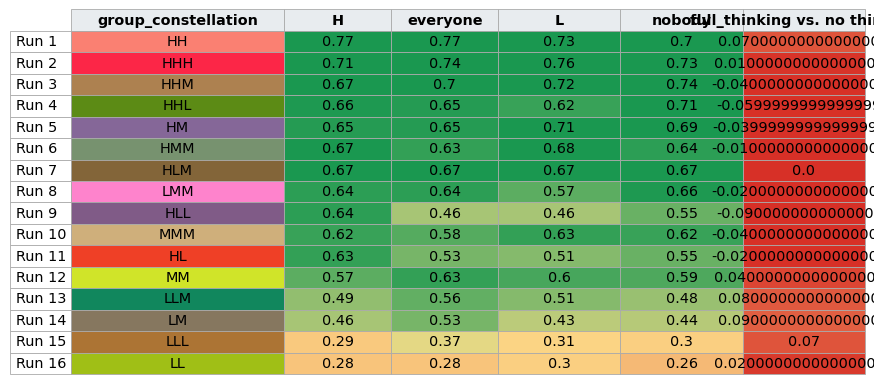

In [13]:
import random
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, get_named_colors_mapping

data = thinking_data.to_numpy()

col_labels = ["group_constellation", "H", "everyone", "L", "nobody", "full_thinking vs. no thinking"]
row_labels = [f"Run {i + 1}" for i in range(len(data))]

# ────────────────────────────────────────────────
# Color gradient: red → white → green for accuracy
# ────────────────────────────────────────────────

colors = ["#d73027", "#fee08b", "#1a9850"]  # red – light yellow – green
all_colors = list(get_named_colors_mapping().values())
cmap = LinearSegmentedColormap.from_list("acc", colors, N=256)


def acc_to_color(value):
    """Map accuracy [0,1] → color"""
    # Optional: clip just in case
    v = max(0.0, min(1.0, float(value)))
    return cmap(v)


# ────────────────────────────────────────────────
# Build 2D list of cell background colors
# ────────────────────────────────────────────────

category_colors = defaultdict(lambda: random.choice(all_colors))

cell_colors = []
for row in data:
    row_colors = []
    for j, val in enumerate(row):
        if j >= 1:  # accuracy column (0-based index 3)
            color = acc_to_color(val * 1.5)
        else:
            color = category_colors[val]
        row_colors.append(color)
    cell_colors.append(row_colors)

# ────────────────────────────────────────────────
# Create figure and table
# ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4.2))  # adjust as needed
ax.axis("off")

table = ax.table(
    cellText=data,
    cellColours=cell_colors,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colWidths=[0.28, 0.14, 0.14, 0.16, 0.16, 0.16],
)

table.auto_set_font_size(False)
table.set_fontsize(10.4)
table.scale(1.2, 1.6)  # horizontal / vertical stretch

# Optional: nicer grid
for (i, j), cell in table.get_celld().items():
    cell.set_edgecolor("#aaaaaa")
    cell.set_linewidth(0.6)
    # Make header row bold / different bg
    if i == 0:
        cell.set_facecolor("#e8ecef")
        cell.set_text_props(weight="bold")

# Optional title

plt.tight_layout()
plt.show()